In [1]:
import sys
import os
sys.path.append('/project/GCRB/Hon_lab/s223695/Data_project/Perturb_seq_shared/')

import pandas as pd
import numpy as np
import scanpy as sc

from sklearn.cluster import KMeans

from scipy.stats import pearsonr
from scipy.optimize import curve_fit,minimize

from itertools import combinations
from sklearn.metrics import pairwise_distances

import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize' : 'large',
                     'pdf.fonttype':42
                    }) 
from matplotlib.backends.backend_pdf import PdfPages

from tqdm import tqdm
from tqdm.contrib.concurrent import process_map

import gc
import warnings
import time
import pickle
import json
import warnings
warnings.simplefilter("ignore")

from sklearn.metrics import pairwise_distances
from multiprocessing import Pool
import torch

from importlib import reload
import util_functions

/project/GCRB/Hon_lab/s223695/anaconda3/envs/scanpy_gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
json_fp = "./config.json"
with open(json_fp, 'r') as fp:
    config = json.load(fp)
    input_file = config["input_data"]["input_file"]
    
sgRNA_file = config["input_data"]["sgRNA_file"]

gRNA_dict_file = config["user_defined_data"]["gRNA_dict_file"]
pca_file = config["user_defined_data"]["pca_file"]
annotation_file = config["user_defined_data"]["annotation_file"]


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

(X,gRNA_dict) = util_functions.load_files(input_file,sgRNA_file,gRNA_dict_file,pca_file)

read input
read pickle
read from dictionary


In [3]:
expression_ann = sc.read_h5ad(input_file)

In [4]:
annotation_file = "full_annotation_df.csv"

In [5]:
annotation_df = pd.read_csv(annotation_file,index_col=0)
annotation_df.head()

,Unnamed: 0,guide_chr,guide_start,guide_end,score,strand,protospacer_target,intended_target_region,gene_target,source,closest_gene,closest_dist,closest_gene_target,closest_dist_target
0,0,chr9,130713821,130713839,.,+,chr9:130713821-130713839(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
1,1,chr9,130713809,130713827,.,+,chr9:130713809-130713827(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
2,2,chr9,130713859,130713877,.,+,chr9:130713859-130713877(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
3,3,chr9,130714246,130714264,.,-,chr9:130714246-130714264(-),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993
4,4,chr9,130713865,130713883,.,+,chr9:130713865-130713883(+),chr9:130713809-130714264,ABL1_ENST00000372348.2,"OpenTargets,CHDgene.au",ABL1,993,ABL1,993


In [6]:
target_gene_list = np.unique(annotation_df["closest_gene_target"])

In [7]:
target_region_dict = {}
target_gRNA_dict = {}

for gene in target_gene_list:
    target_list = np.unique(annotation_df[annotation_df["closest_gene_target"]== \
                                          gene]["gene_target"])
    target_region_dict[gene] = target_list

for gene in target_gene_list:
    target_list = np.unique(annotation_df[annotation_df["closest_gene_target"]== \
                                          gene]["protospacer_target"])
    target_gRNA_dict[gene] = target_list

In [8]:
gRNA_clear_list = pd.read_csv("/project/GCRB/Hon_lab/s223695/Data_project/20240903_CP2/Step1_sgRNA_outlier_pval_clear.csv",
                              index_col=0
                             )
gRNA_clear_list = gRNA_clear_list.index.tolist()

In [9]:
pval_sig_df = pd.read_csv("./Step2_pval_target_significant.csv",index_col=0)

In [10]:
sig_region_list = pval_sig_df["region_name"].values
sig_promoter_list = sig_region_list[[
    not (x.startswith("OR") or x.startswith("Element")) for x in sig_region_list]
]

In [11]:
sig_gene_name_tuple = []
for name in sig_promoter_list:
    annotation_sig_pro = annotation_df[annotation_df["gene_target"]==name]
    target_gene = annotation_sig_pro["closest_gene_target"].values[0]
    sig_gene_name_tuple += [(name,target_gene)]

In [12]:
gRNA_region_dict = {}

OR_gRNA_list = [i for i in gRNA_dict.keys() if i.startswith("OR")]
for gRNA_tmp in OR_gRNA_list:
    gene_name = gRNA_tmp.split("-")[0]
    if gRNA_tmp in gRNA_dict.keys():
        if gene_name in gRNA_region_dict.keys():
            gRNA_region_dict[gene_name] += [gRNA_tmp]
        else:
            gRNA_region_dict[gene_name] = [gRNA_tmp]

for index,row in annotation_df.iterrows():
    if row.protospacer_target in gRNA_dict.keys():
        if row.intended_target_region in gRNA_region_dict.keys():
            gRNA_region_dict[row.intended_target_region] += [row.protospacer_target]
        else:
            gRNA_region_dict[row.intended_target_region] = [row.protospacer_target]
for key in gRNA_region_dict.keys():
    gRNA_region_dict[key] = np.unique(gRNA_region_dict[key])

In [13]:
non_target_df = pd.read_csv("./Step2_non_targeting_gRNA_clean.csv")
gRNA_region_dict["non-targeting"] = non_target_df.values.reshape(-1).tolist()

In [14]:
def convert_name_region(target_name):
    return annotation_df[annotation_df["gene_target"]==target_name]["intended_target_region"].values[0]
def convert_region_name(target_region):
    return annotation_df[annotation_df["intended_target_region"]==target_region]["gene_target"].values[0]

<h4>Strategy</h4>
Only focus on highly expressed gene<br>
find 1 gRNA with strongest repression and highest energy distance<br>
Calculate repression level and promoter enhancer energy distance

In [15]:
target_index = np.argwhere(np.isin(expression_ann.var.index,[name for region,name in sig_gene_name_tuple])).reshape(-1)
target_list_tmp = np.array(expression_ann.var.index.tolist())[target_index]
target_name_idx_dict = dict(zip(target_list_tmp,target_index))

ext_arr = np.exp(expression_ann.raw.X[:,target_index].toarray())-1
ext_arr = pd.DataFrame(ext_arr,
                       index=expression_ann.obs.index,
                       columns=target_list_tmp
                      )

In [16]:
non_targeting_cells_pick = np.concatenate([gRNA_dict[x] for x in gRNA_region_dict["non-targeting"]])
non_targeting_cells_pick = np.unique(non_targeting_cells_pick)
np.random.seed(1234)
non_targeting_cells_pick = np.random.choice(non_targeting_cells_pick,20000,replace=False)

In [17]:
ext_arr.loc[non_targeting_cells_pick,"TBX5"].iloc[:10]

CGCTATCGTGCGGTAA-3     0.000000
CTAACTTTCATCGCTC-5     4.402378
AAATGCCTCCTGCAGG-12    0.000000
TATCAGGGTATAATGG-10    0.000000
TAGAGCTCAGCTTCGG-6     0.000000
CATGACAAGGCCATAG-6     0.000000
AGGTCCGGTCGTTGTA-19    0.000000
CGACCTTGTCTCTTAT-1     0.000000
TGACTTTGTTGGTGGA-8     0.808900
AACTCAGTCCCTAATT-12    0.000000
Name: TBX5, dtype: float32

In [18]:
non_targeting_cells_pick[:10]

array(['CGCTATCGTGCGGTAA-3', 'CTAACTTTCATCGCTC-5', 'AAATGCCTCCTGCAGG-12',
       'TATCAGGGTATAATGG-10', 'TAGAGCTCAGCTTCGG-6', 'CATGACAAGGCCATAG-6',
       'AGGTCCGGTCGTTGTA-19', 'CGACCTTGTCTCTTAT-1', 'TGACTTTGTTGGTGGA-8',
       'AACTCAGTCCCTAATT-12'], dtype='<U19')

In [19]:
convert_name_region("ACTN2_P1P2")

'chr1:236686500-236686619'

In [21]:
res_nt_dist = []
for target,gene in tqdm(sig_gene_name_tuple):
    test_regions = np.unique(annotation_df[annotation_df["closest_gene_target"]==gene]["intended_target_region"].values)
    
    test_gRNAs = np.unique(np.concatenate([gRNA_region_dict[key] for key in test_regions]))
    test_gRNAs = [test_gRNA for test_gRNA in test_gRNAs if len(gRNA_dict[test_gRNA])>50]
    
    exp_arr = ext_arr.loc[non_targeting_cells_pick,:][gene].values
    mean_exp_nt = np.mean(exp_arr)
    res_nt_dist += [("non-targeting",mean_exp_nt,1.0,0,len(non_targeting_cells_pick),gene)]
    
    for test_gRNA in test_gRNAs:
        exp_arr = ext_arr.loc[gRNA_dict[test_gRNA],:][gene].values
        mean_exp = np.mean(exp_arr)
        mean_exp_relative = mean_exp/mean_exp_nt
        
        cell_test1 = gRNA_dict[test_gRNA]
        cell_test2 = non_targeting_cells_pick
        obs_edist = util_functions.permutation_test(X,cell_test1,cell_test2,device,1,1,
                                                    return_permute=False).item()
        
        res_nt_dist += [(test_gRNA,mean_exp,mean_exp_relative,obs_edist,len(cell_test1),gene)]

    

100%|██████████| 113/113 [25:14<00:00, 13.40s/it]


In [22]:
def get_region_from_gRNA(gRNA_name):
    if gRNA_name == "non-targeting":
        return "non-targeting"
    
    for key in gRNA_region_dict.keys():
        if gRNA_name in gRNA_region_dict[key]:
            return convert_region_name(key)
    return None

In [23]:
res_nt_dist_df = pd.DataFrame(res_nt_dist,columns=["gRNA_name","expression","relative_expression",
                                                   "edist","cell_num","target_gene"])

In [24]:
res_nt_dist_df["target_name"] = res_nt_dist_df["gRNA_name"].apply(get_region_from_gRNA)

In [25]:
res_nt_dist_df.to_csv("./gRNA_enhancer_nt_edist.csv")

In [26]:
res_nt_dist_df.head()

,gRNA_name,expression,relative_expression,edist,cell_num,target_gene,target_name
0,non-targeting,1.427053,1.000000,0.000000,20000,ACTN2,non-targeting
1,chr1:236686500-236686518(-),0.242010,0.169587,22.168823,82,ACTN2,ACTN2_P1P2
2,chr1:236686531-236686549(-),0.166434,0.116628,26.785767,97,ACTN2,ACTN2_P1P2
3,chr1:236686545-236686563(-),0.186948,0.131003,10.886353,226,ACTN2,ACTN2_P1P2
4,chr1:236686595-236686613(-),0.200017,0.140161,15.450806,233,ACTN2,ACTN2_P1P2


In [27]:
test_gene_df = res_nt_dist_df[(res_nt_dist_df["gRNA_name"]=="non-targeting") &
                              (res_nt_dist_df["expression"]>0.1) & 
                              (res_nt_dist_df["expression"]<2)
                             ]
test_gene_df.head()

,gRNA_name,expression,relative_expression,edist,cell_num,target_gene,target_name
0,non-targeting,1.427053,1.0,0.0,20000,ACTN2,non-targeting
7,non-targeting,0.183467,1.0,0.0,20000,ACVR2B,non-targeting
114,non-targeting,0.387082,1.0,0.0,20000,AFF4,non-targeting
179,non-targeting,0.368506,1.0,0.0,20000,BMPR2,non-targeting
234,non-targeting,0.367492,1.0,0.0,20000,BPTF,non-targeting


In [28]:
test_gene_list = test_gene_df["target_gene"].values

In [29]:
referene_gRNAs = []
for target in test_gene_list:
    res_nt_dist_df_selected = res_nt_dist_df[(res_nt_dist_df["target_gene"]==target) &
                                             (np.isin(res_nt_dist_df["gRNA_name"],gRNA_clear_list))
                                            ].sort_values("expression")
    referene_gRNAs += [(target,res_nt_dist_df_selected["gRNA_name"].values.tolist())]

In [30]:
res = []

for gene_name,reference_gRNAs in tqdm(referene_gRNAs):
    reference_cells = np.unique(np.concatenate([gRNA_dict[x] for x in reference_gRNAs]))

    test_gRNAs = target_gRNA_dict[gene_name]
    test_gRNAs = [x for x in test_gRNAs if x in gRNA_dict.keys()]
    test_gRNAs = [test_gRNA for test_gRNA in test_gRNAs if len(gRNA_dict[test_gRNA])>50]

    for test_gRNA in test_gRNAs:
        exp_arr = ext_arr.loc[gRNA_dict[test_gRNA],:][gene_name].values
        mean_exp = np.mean(exp_arr)

        cell_test1 = gRNA_dict[test_gRNA]
        cell_test2 = reference_cells
        
        obs_edist = util_functions.permutation_test(X,cell_test1,cell_test2,device,1,1,
                                                    return_permute=False).item()

        res += [(test_gRNA,mean_exp,obs_edist,len(cell_test1),gene_name)]

    exp_arr = ext_arr.loc[non_targeting_cells_pick,:][gene_name].values

    cell_test1 = non_targeting_cells_pick
    cell_test2 = reference_cells
    
    obs_edist = util_functions.permutation_test(X,non_targeting_cells_pick,cell_test2,device,1,1,
                                                return_permute=False).item()

    mean_exp = np.mean(exp_arr)
    res += [("non-targeting",mean_exp,obs_edist,len(non_targeting_cells_pick),gene_name)]

100%|██████████| 56/56 [25:33<00:00, 27.39s/it]   


In [31]:
res_df = pd.DataFrame(res)
res_df.columns = ["gRNA_name","expression","edist","cell_num","target_gene"]

In [32]:
res_df["target_name"] = res_df["gRNA_name"].apply(get_region_from_gRNA)
res_df["is_clear"] = res_df["gRNA_name"].apply(lambda x: x in gRNA_clear_list)

In [33]:
res_df.head()

,gRNA_name,expression,edist,cell_num,target_gene,target_name,is_clear
0,chr1:236686500-236686518(-),0.242010,28.231201,82,ACTN2,ACTN2_P1P2,False
1,chr1:236686531-236686549(-),0.166434,15.448486,97,ACTN2,ACTN2_P1P2,True
2,chr1:236686545-236686563(-),0.186948,10.875977,226,ACTN2,ACTN2_P1P2,True
3,chr1:236686595-236686613(-),0.200017,4.378906,233,ACTN2,ACTN2_P1P2,True
4,chr1:236686598-236686616(-),0.151940,3.578613,268,ACTN2,ACTN2_P1P2,True


In [34]:
res_df.to_csv("./gRNA_enhancer_edist.csv")

#### Fit with linear and curve 

In [35]:
#logisitic curve
def logistic_func(x, a, b, c):
    return a / (1 + np.exp(-b * (x - c)))

def exp_func(x,a,b):
    return a*(np.exp(-b*(x-1))-1)

def linear_func(x,a,b):
    return a * (x-1) + b

In [1]:
sig_gene_name_tuple[:5]

NameError: name 'sig_gene_name_tuple' is not defined

In [37]:
res_nt_dist_df.head()

,gRNA_name,expression,relative_expression,edist,cell_num,target_gene,target_name
0,non-targeting,1.427053,1.000000,0.000000,20000,ACTN2,non-targeting
1,chr1:236686500-236686518(-),0.242010,0.169587,22.168823,82,ACTN2,ACTN2_P1P2
2,chr1:236686531-236686549(-),0.166434,0.116628,26.785767,97,ACTN2,ACTN2_P1P2
3,chr1:236686545-236686563(-),0.186948,0.131003,10.886353,226,ACTN2,ACTN2_P1P2
4,chr1:236686595-236686613(-),0.200017,0.140161,15.450806,233,ACTN2,ACTN2_P1P2


In [38]:
stat_df = pd.DataFrame(columns=["num_valid_gRNA","pearson_r","expression_range",
                                "exp_0","exp_1","lin_0","lin_1","err_exp","err_lin"])
for target,gene in tqdm(sig_gene_name_tuple):
    res_target = res_nt_dist_df[(res_nt_dist_df["target_gene"]==gene) &
                                (res_nt_dist_df["gRNA_name"]!="non-targeting") &
                                (res_nt_dist_df["relative_expression"]<0.9)
                       ]
    num_valid_gRNA = res_target.shape[0]
    exp_range = res_target["relative_expression"].max()-res_target["relative_expression"].min()
    
    if (num_valid_gRNA>3) and (exp_range>0.2):   
        res_rankcorr = pearsonr(res_target["relative_expression"],res_target["edist"])
        x = np.append(res_target["relative_expression"].values,[1.0])
        y = np.append(res_target["edist"].values,[0.0])
        params_exp, _ = curve_fit(exp_func, x, y, p0=[1,2],maxfev = 5000)
        params_lin, _ = curve_fit(linear_func, x, y, p0=[-1,1],maxfev = 5000)
        
        y_fit_exp = exp_func(x,params_exp[0],params_exp[1])
        y_fit_lin = linear_func(x,params_exp[0],params_exp[1])
        err_exp = np.sum(np.power(y-y_fit_exp,2))
        err_lin = np.sum(np.power(y-y_fit_lin,2))
        
        stat_df.loc[gene] = [num_valid_gRNA,res_rankcorr.statistic,exp_range,
                                    params_exp[0],params_exp[1],
                                    params_lin[0],params_lin[1],
                                    err_exp,err_lin
                                   ]
stat_df["err_exp/lin"] = stat_df["err_exp"]/stat_df["err_lin"]

100%|██████████| 113/113 [00:01<00:00, 64.44it/s]


In [39]:
stat_df.sort_values("pearson_r",ascending=False).tail()

,num_valid_gRNA,pearson_r,expression_range,exp_0,exp_1,lin_0,lin_1,err_exp,err_lin,err_exp/lin
MYOCD,49.0,-0.816759,0.735821,138806.675048,0.000406,-51.745708,2.395162,4300.411228,1.578351e+11,2.724623e-08
EHMT1,5.0,-0.818322,0.540371,28.018114,1.491896,-85.478312,-7.070753,1227.359673,2.211696e+04,5.549404e-02
RAD21,5.0,-0.820325,0.479527,469.119227,0.145248,-77.719666,-3.781518,666.347624,4.761823e+05,1.399354e-03
NKX2-5,28.0,-0.961176,0.790365,66.209714,1.189728,-150.385314,-11.003169,5737.497189,4.093873e+05,1.401484e-02
NIPBL,5.0,-0.972142,0.376265,86.387300,0.968126,-118.994769,-4.815819,166.043012,3.302763e+04,5.027397e-03


In [40]:
res_nt_dist_df.head()

,gRNA_name,expression,relative_expression,edist,cell_num,target_gene,target_name
0,non-targeting,1.427053,1.000000,0.000000,20000,ACTN2,non-targeting
1,chr1:236686500-236686518(-),0.242010,0.169587,22.168823,82,ACTN2,ACTN2_P1P2
2,chr1:236686531-236686549(-),0.166434,0.116628,26.785767,97,ACTN2,ACTN2_P1P2
3,chr1:236686545-236686563(-),0.186948,0.131003,10.886353,226,ACTN2,ACTN2_P1P2
4,chr1:236686595-236686613(-),0.200017,0.140161,15.450806,233,ACTN2,ACTN2_P1P2


In [41]:
stat_df

,num_valid_gRNA,pearson_r,expression_range,exp_0,exp_1,lin_0,lin_1,err_exp,err_lin,err_exp/lin
ACVR2B,17.0,-0.198109,0.776426,106699.924044,0.000267,-11.964408,10.595976,3790.798589,5.467088e+10,6.933854e-08
ADNP2,38.0,-0.147051,0.894728,129112.994053,0.000294,-13.187020,15.971862,20266.464700,1.898978e+11,1.067230e-07
AFF4,28.0,-0.105058,0.755079,220901.842364,0.000159,-7.738646,17.222204,7792.242064,3.713118e+11,2.098571e-08
BMPR2,5.0,-0.352388,0.274990,48347.358295,0.001547,-79.316160,-2.069516,3324.452261,2.359926e+09,1.408710e-06
BNC1,41.0,-0.021248,0.830129,97561.520783,0.000309,-7.139659,17.521215,15469.973962,2.028895e+11,7.624829e-08
...,...,...,...,...,...,...,...,...,...,...
ZNF460,59.0,-0.234526,0.846760,149277.690750,0.000213,-13.941492,8.946766,10040.591802,2.367213e+11,4.241525e-08
ZNF649,51.0,-0.178845,0.886070,148354.706761,0.000202,-14.211128,9.646496,18085.481383,3.280659e+11,5.512759e-08
ZNF787,33.0,-0.636524,0.789511,140160.199133,0.000357,-44.360766,3.271817,7075.552958,1.451146e+11,4.875838e-08
ZNF814,81.0,-0.050688,0.612690,133005.643487,0.000244,-5.041723,12.930982,18204.666275,2.489114e+11,7.313714e-08


In [58]:
stat_df.to_csv("edist_lin_exp_stat.csv")

#### Plot figure

In [57]:
with PdfPages("edist_nt_gRNA_plot_element.pdf") as pdf:
    for target,gene in tqdm(sig_gene_name_tuple):
        
        if not gene in stat_df.index:
            continue
        fig,ax=plt.subplots(figsize=(7,4))
        res_df_plot = res_nt_dist_df[res_nt_dist_df["target_gene"]==gene].copy()
        
        sns.scatterplot(data=res_df_plot,x="relative_expression",y="edist",
                        hue="target_name",ax=ax)
        ax.axvline(1,c="black",linestyle="--")
        ax.axhline(0,c="black",linestyle="--")

        a_exp,b_exp,a_lin,b_lib = stat_df.loc[gene,["exp_0","exp_1","lin_0","lin_1"]]

        x = np.arange(0,1.1,0.025)
        y_exp = exp_func(x,a_exp,b_exp)
        y_lin = linear_func(x,a_lin,b_lib)
        ax.plot(x, y_exp)
        ax.plot(x, y_lin)
        ax.set_ylim(0,np.max(res_df_plot["edist"])*1.1)

        ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
        plt.tight_layout()
        
        pdf.savefig()
        plt.close()


100%|██████████| 113/113 [00:12<00:00,  9.01it/s]


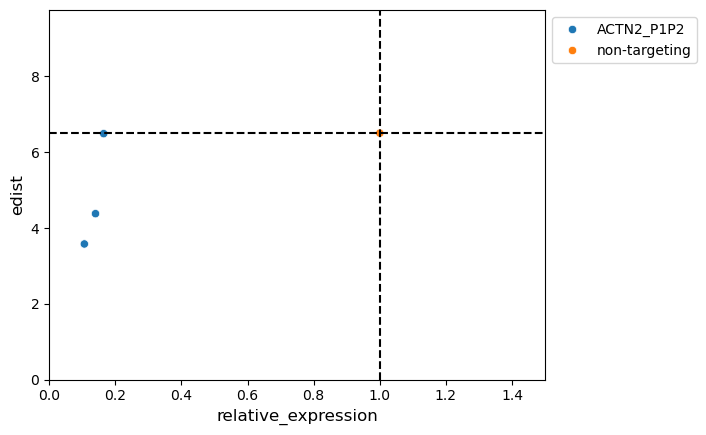

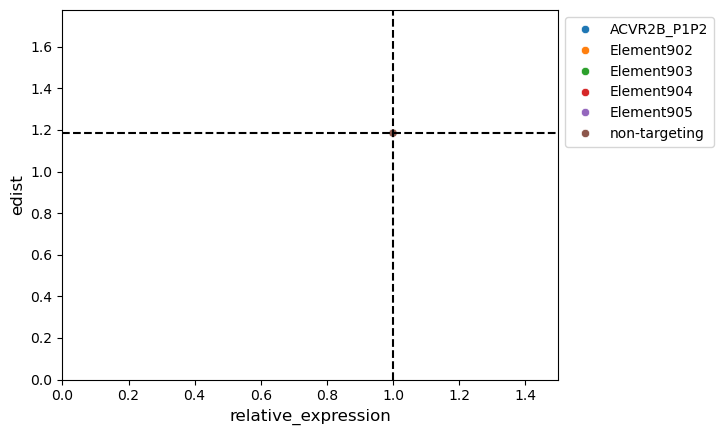

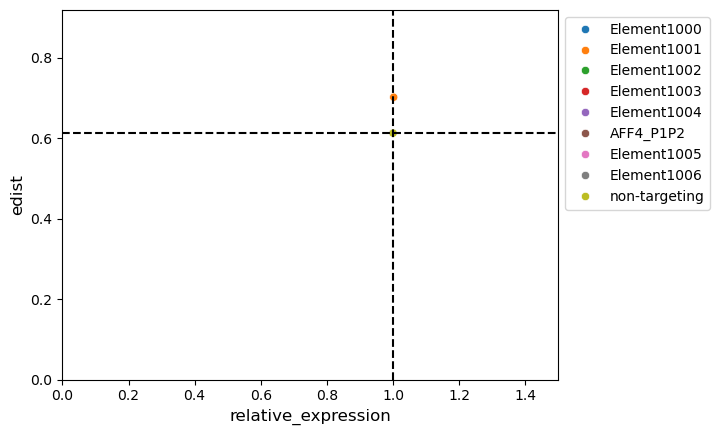

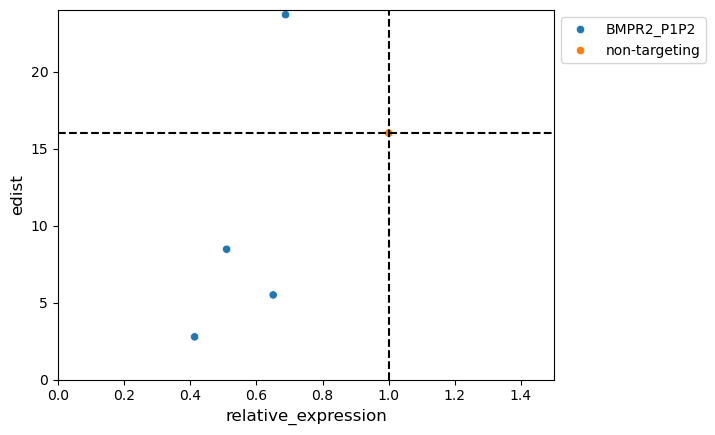

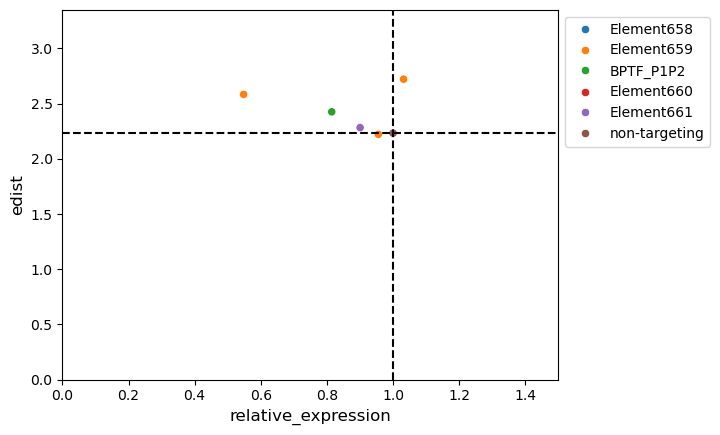

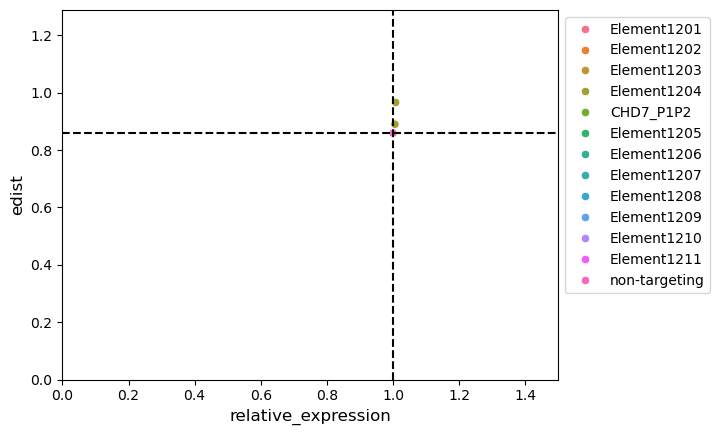

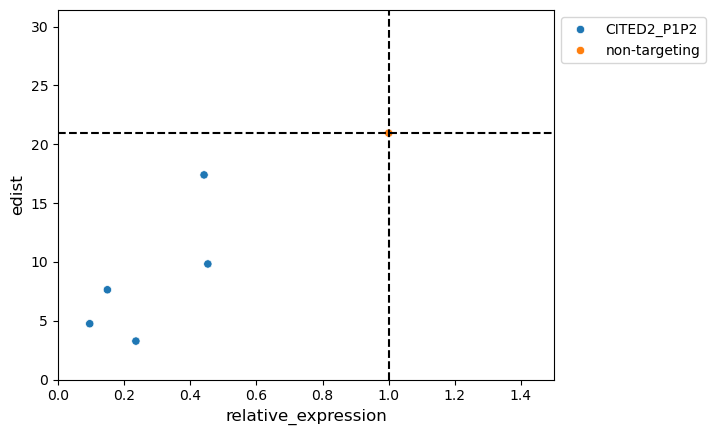

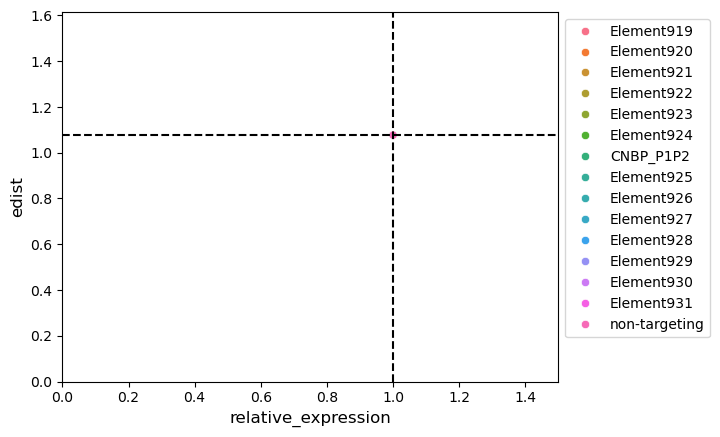

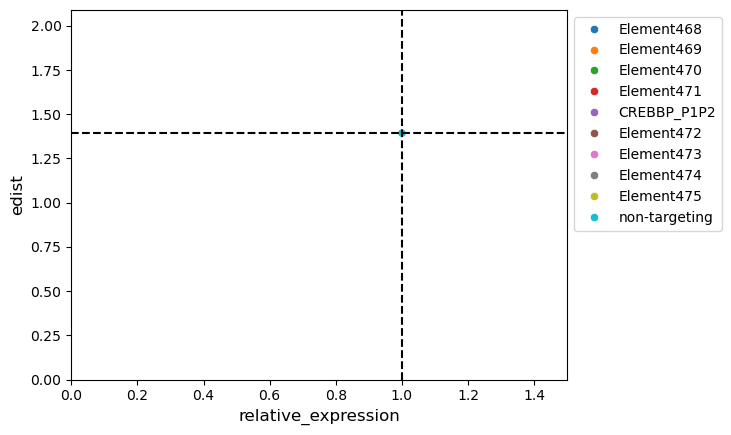

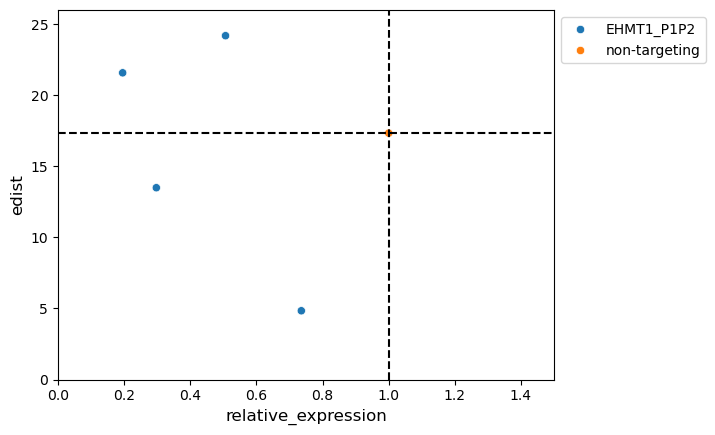

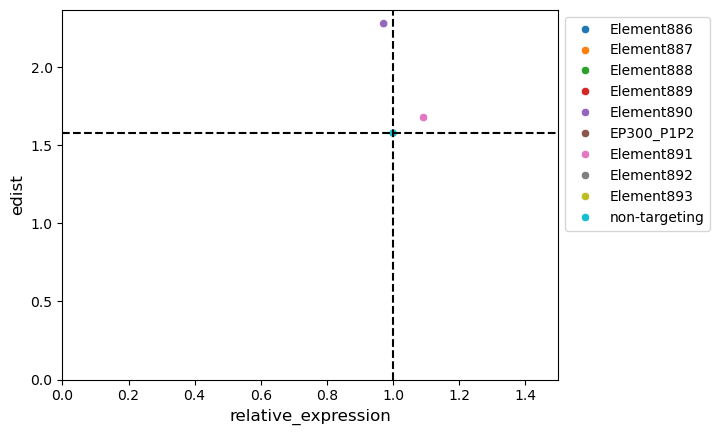

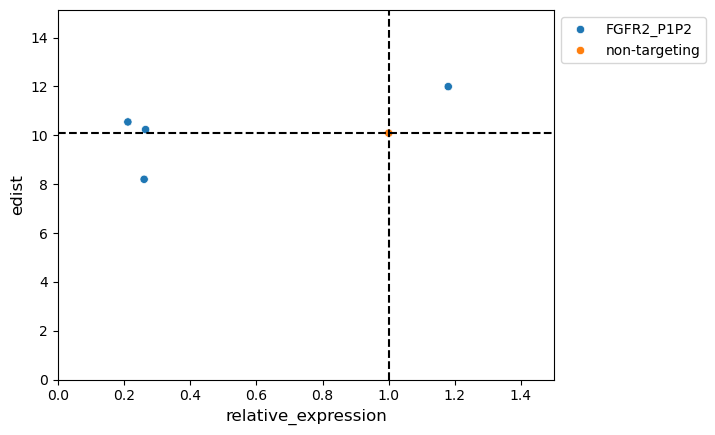

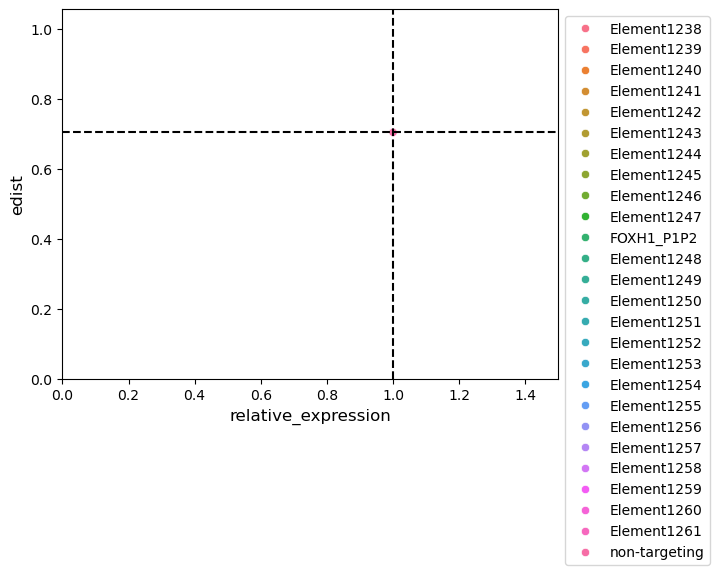

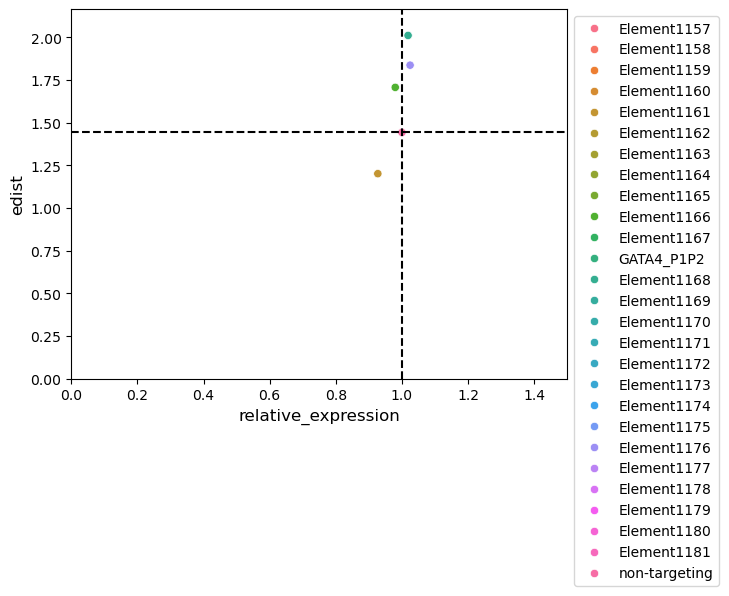

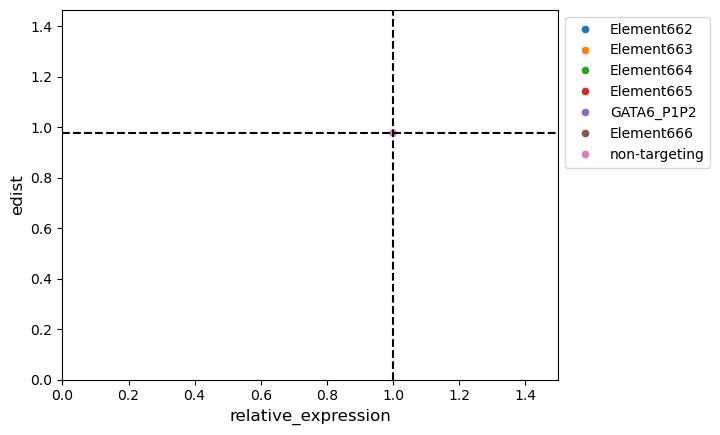

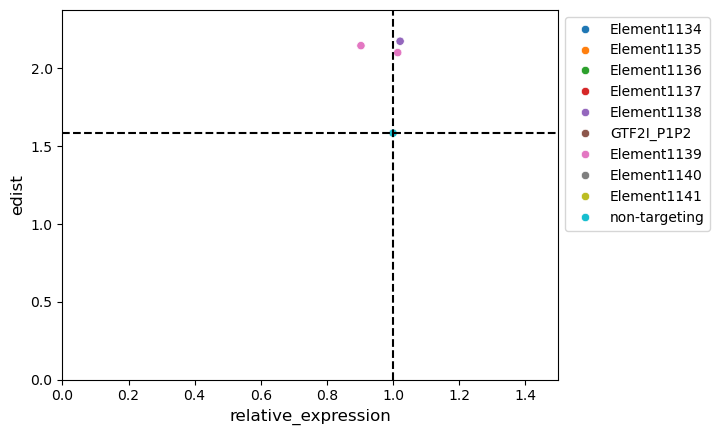

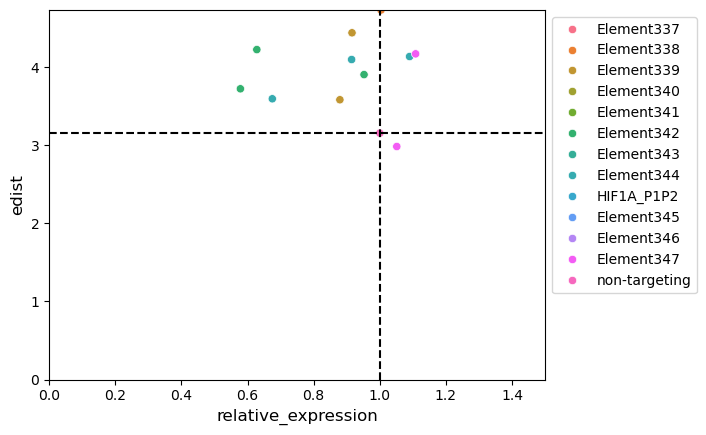

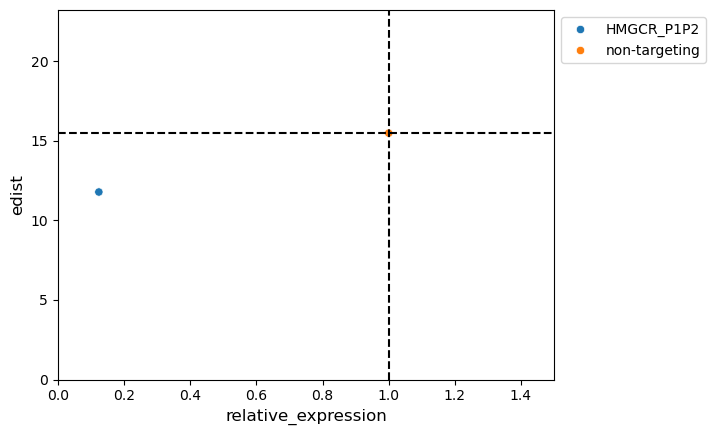

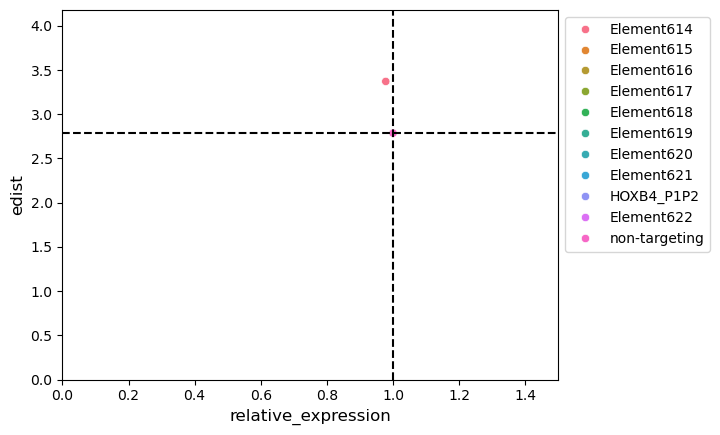

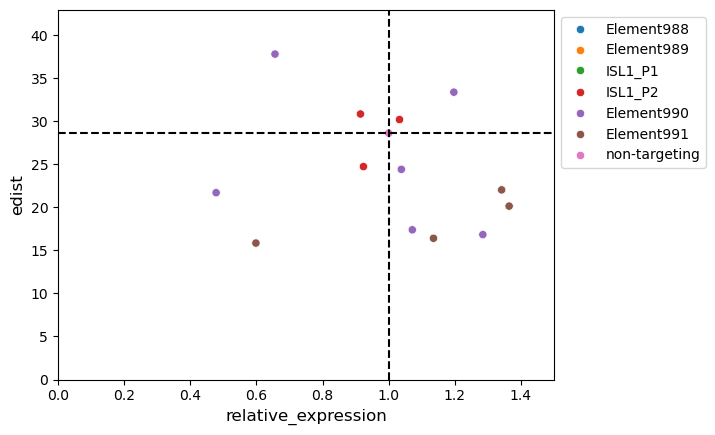

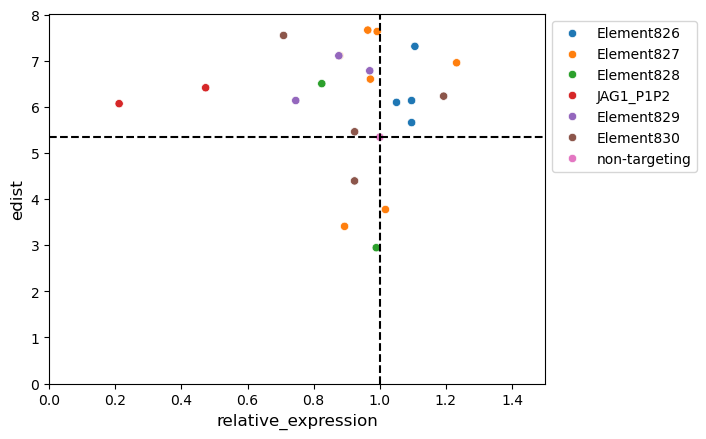

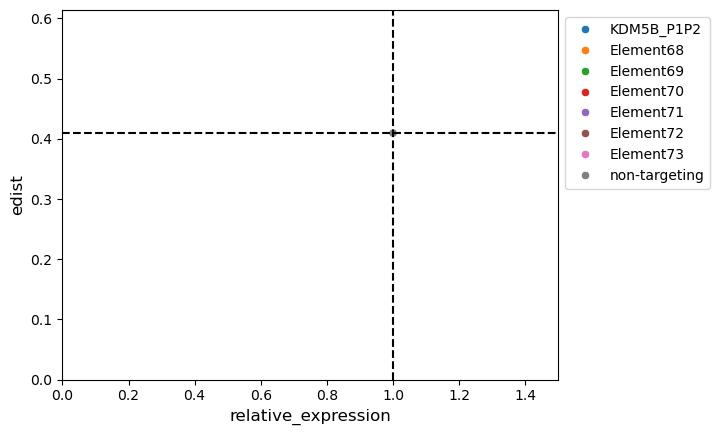

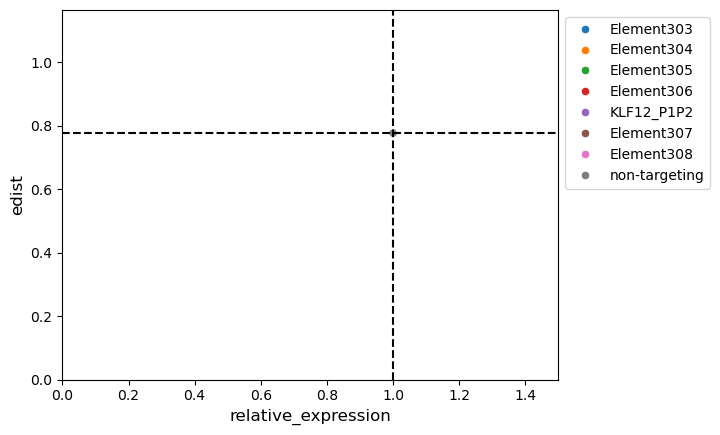

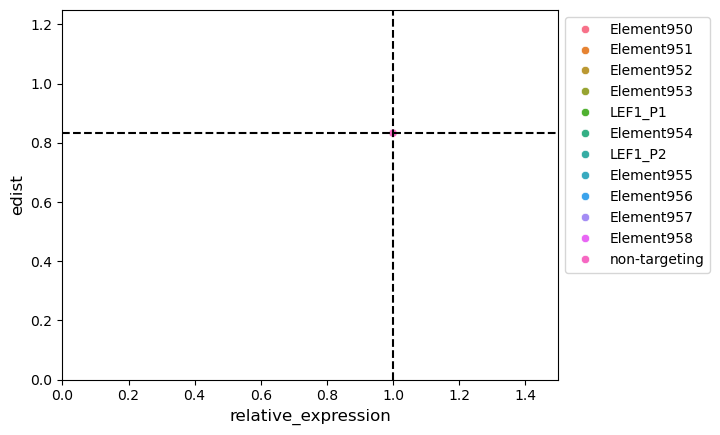

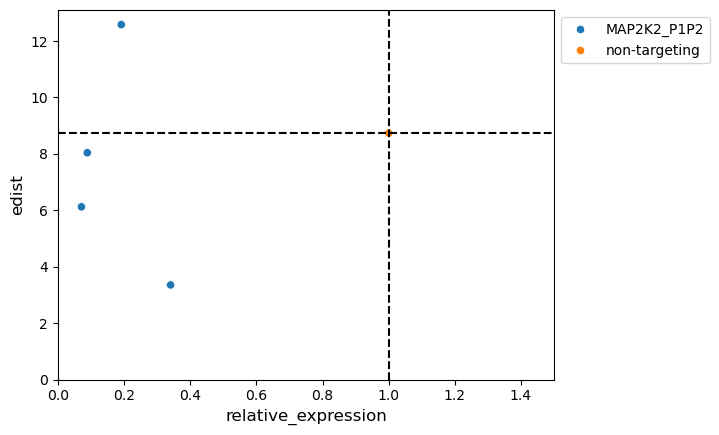

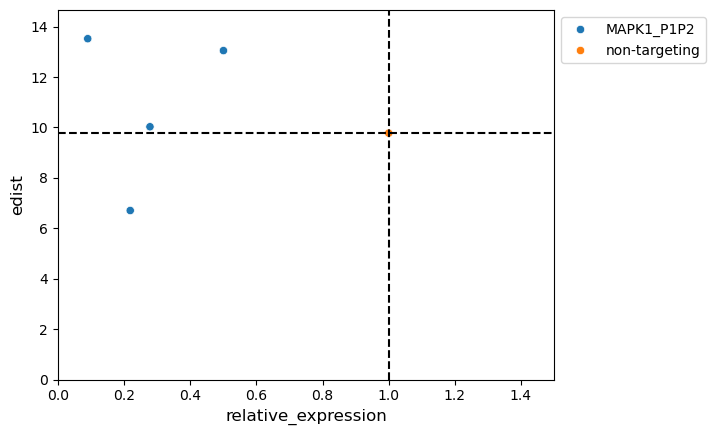

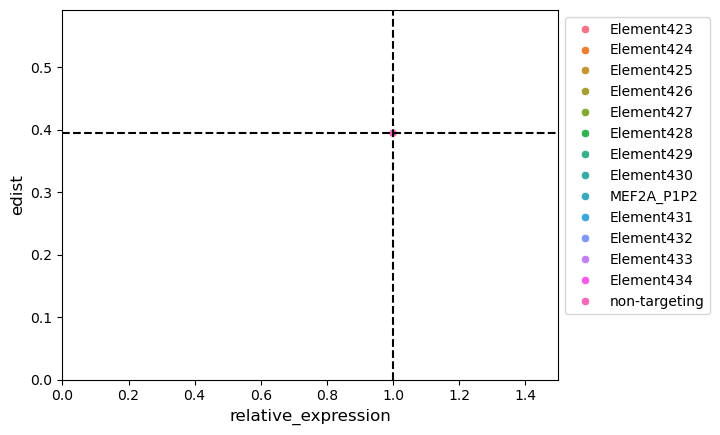

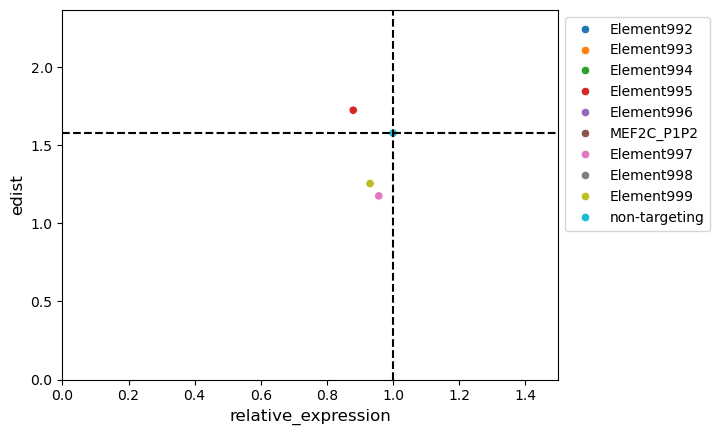

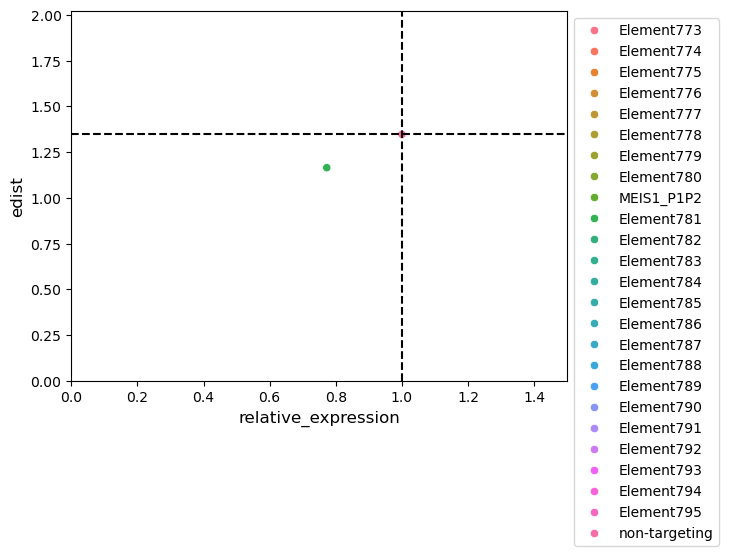

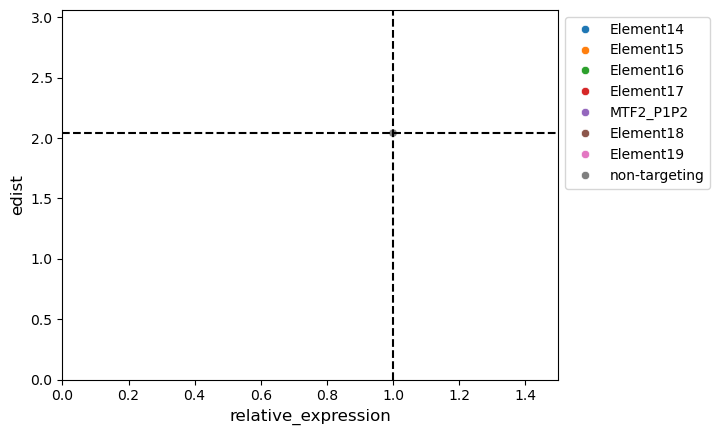

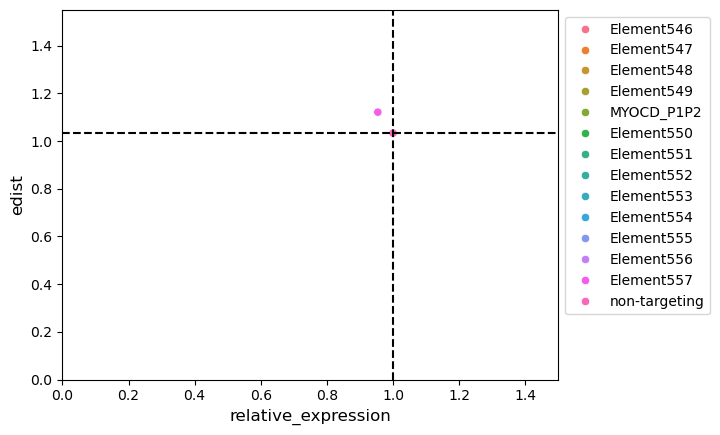

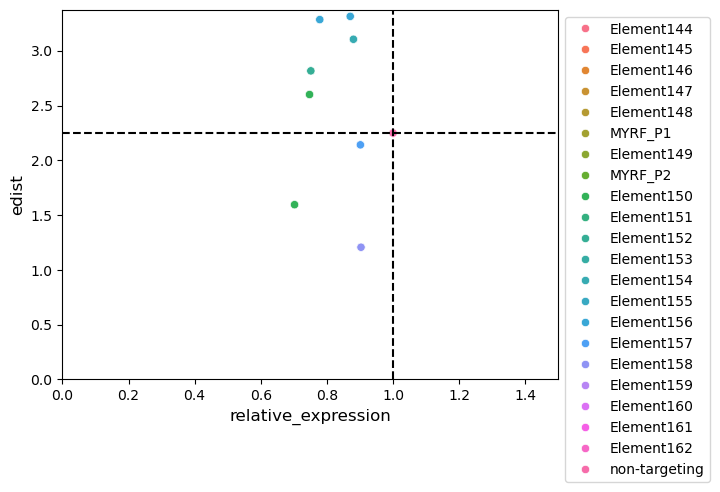

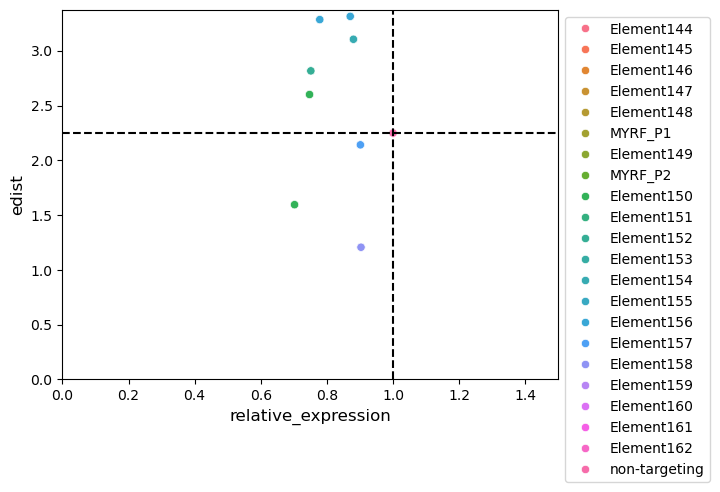

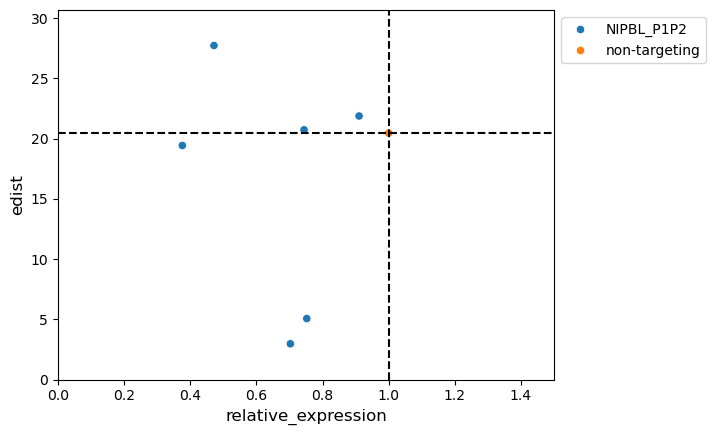

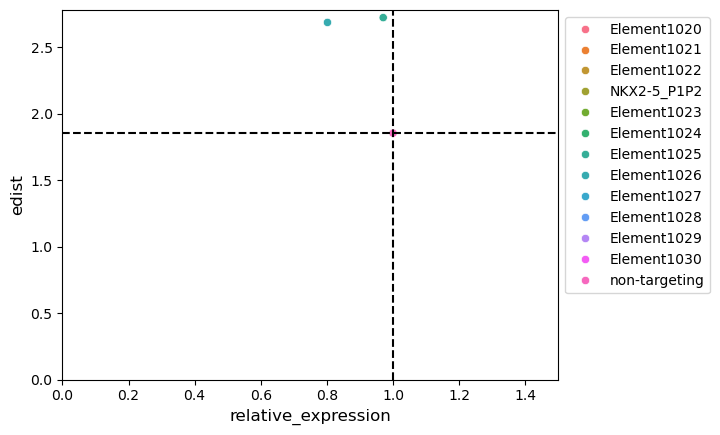

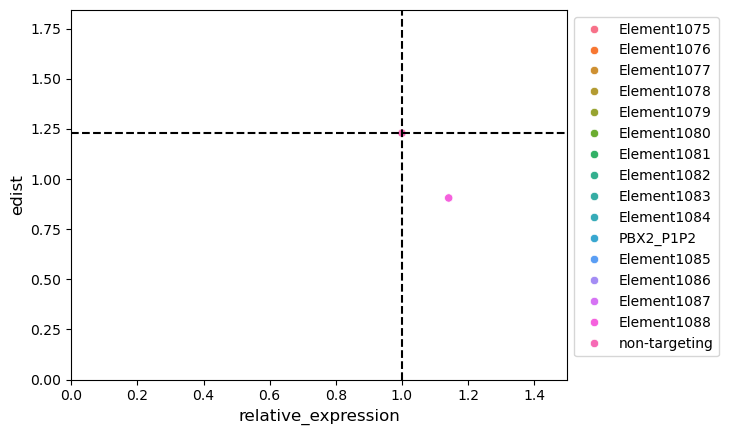

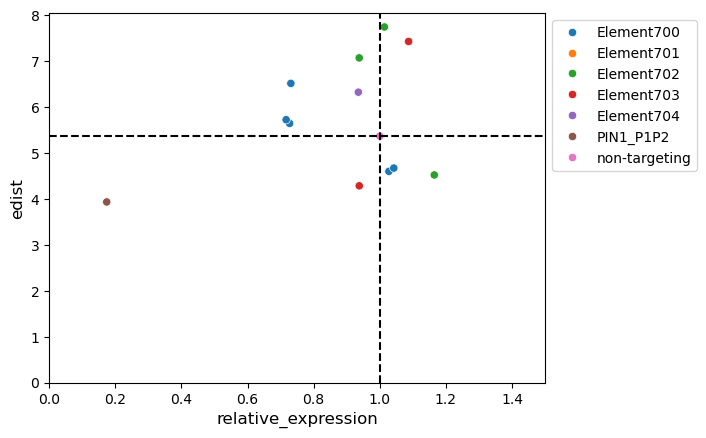

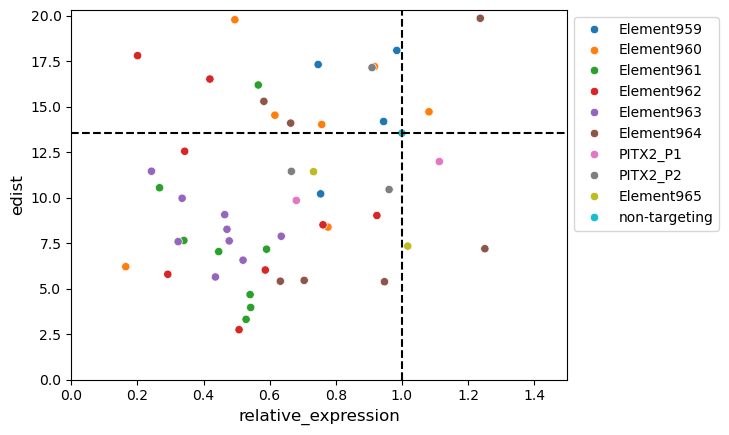

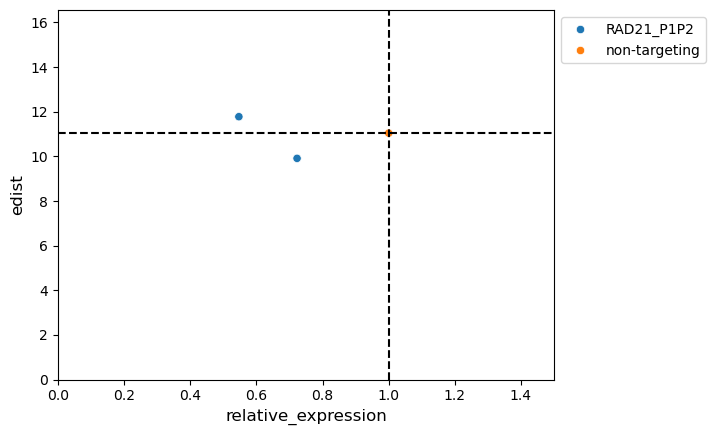

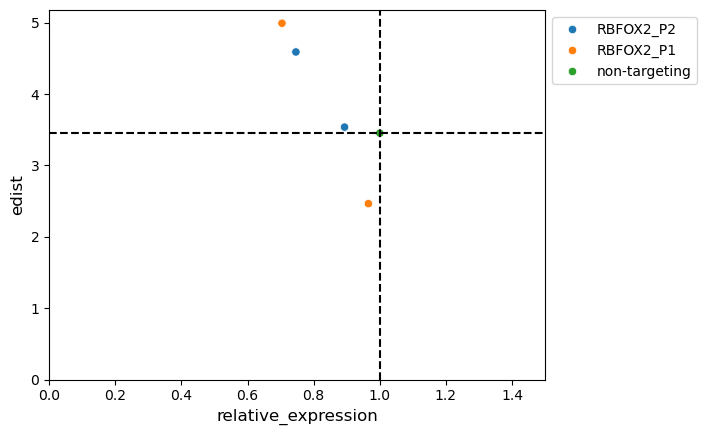

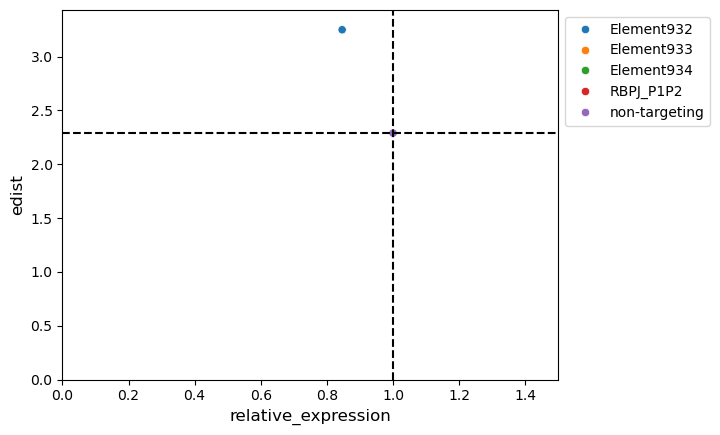

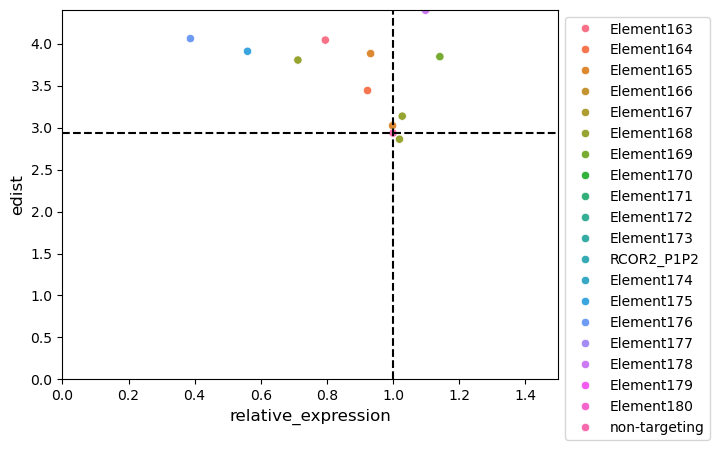

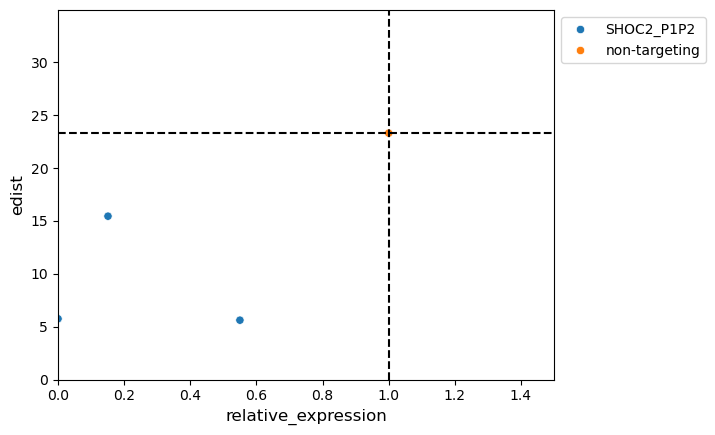

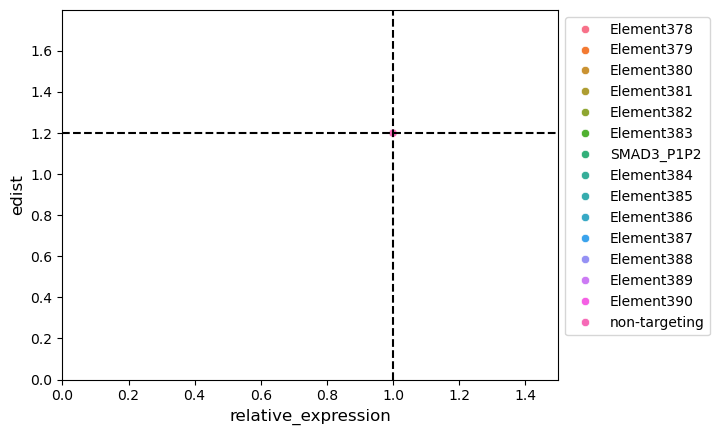

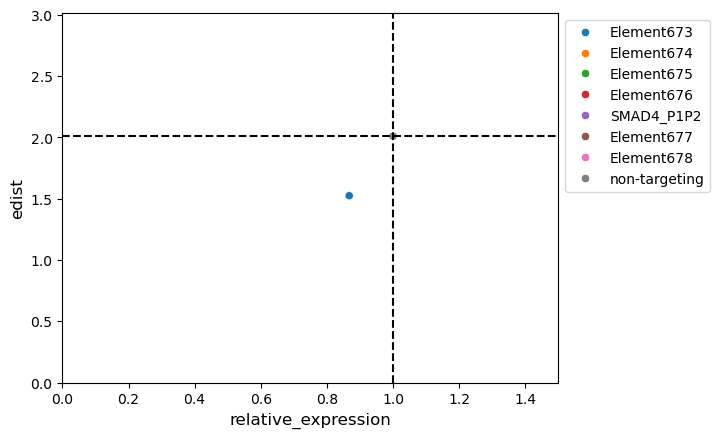

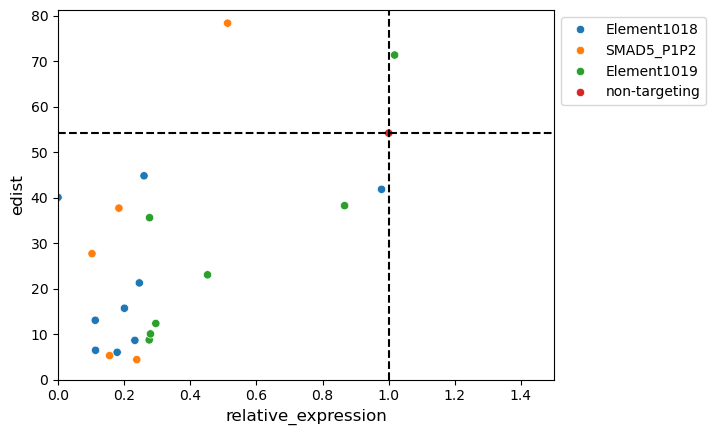

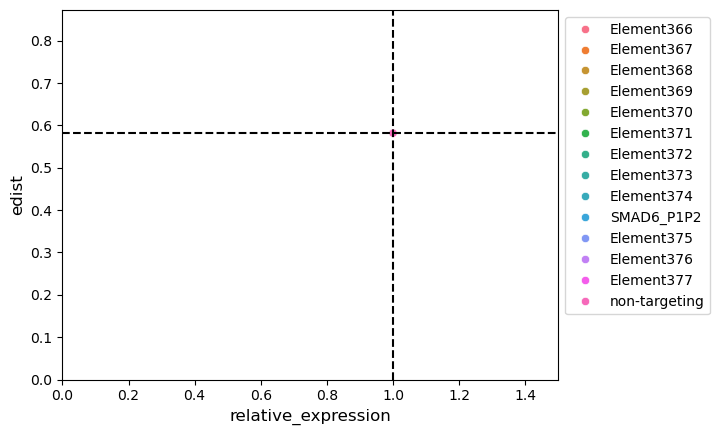

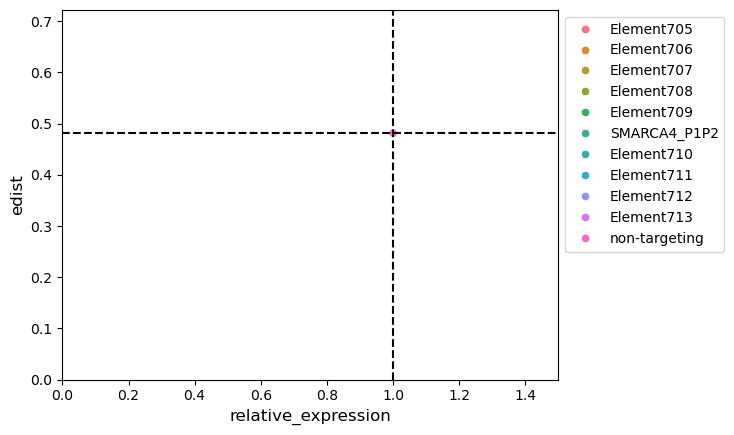

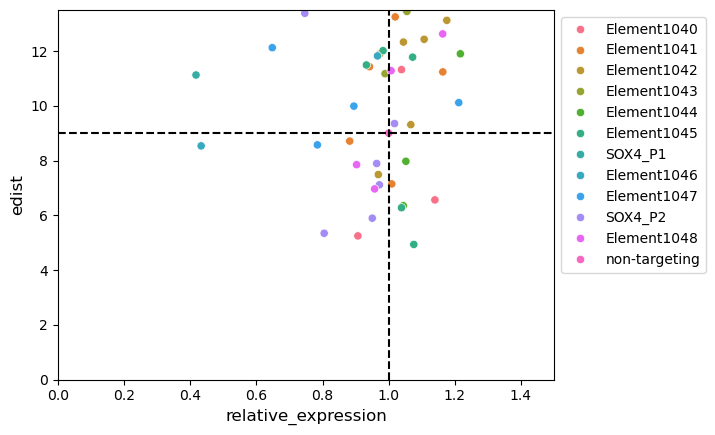

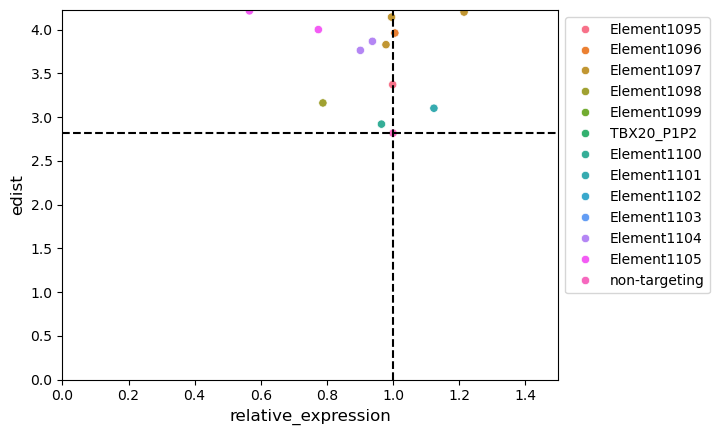

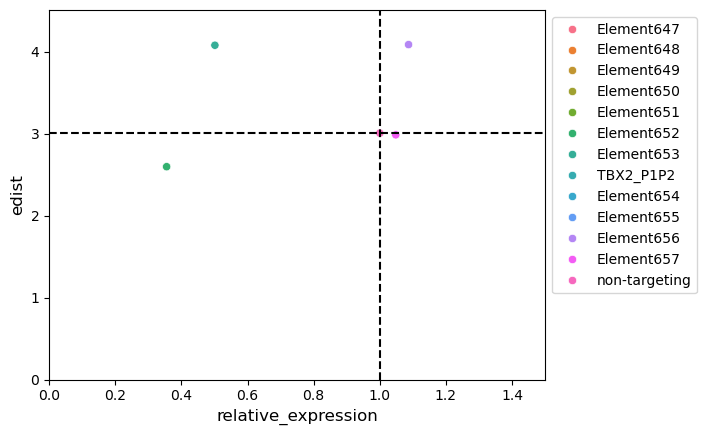

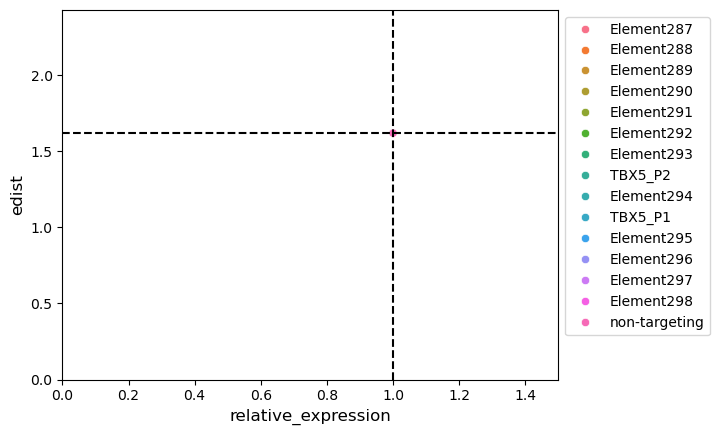

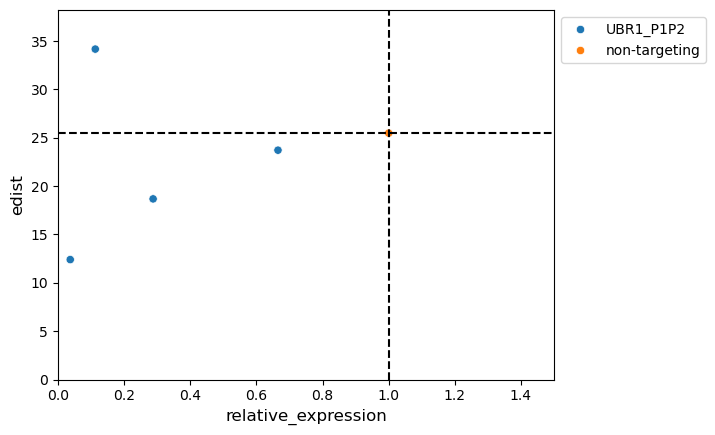

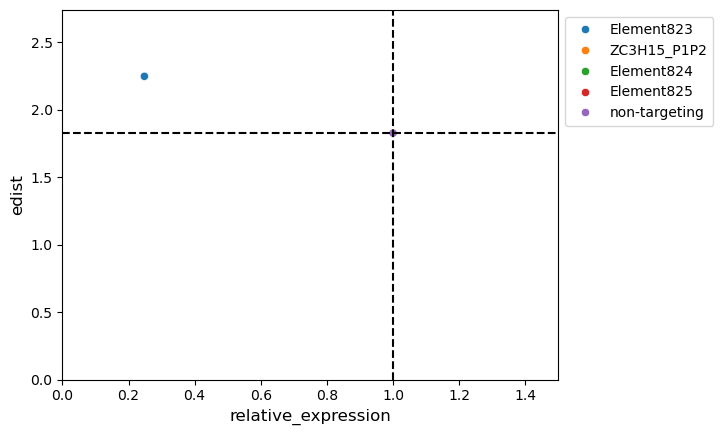

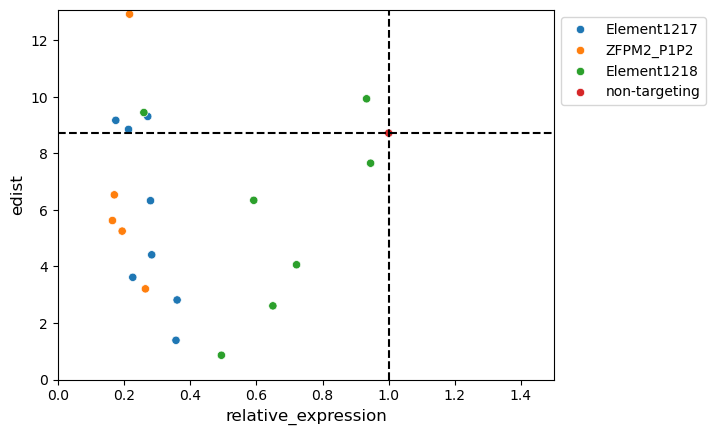

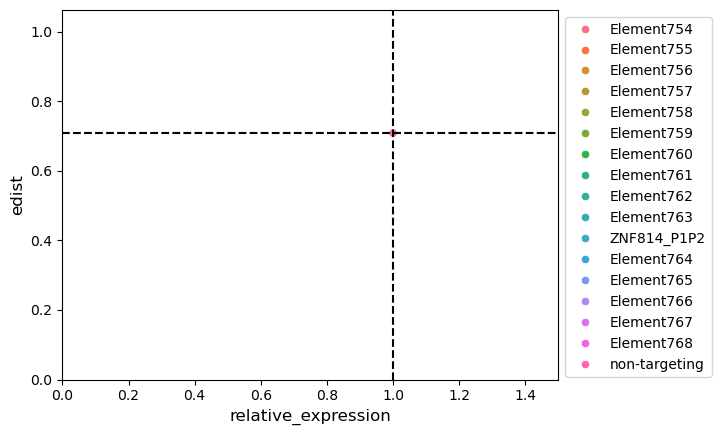

In [53]:
with PdfPages("edist_gRNA_plot_element.pdf") as pdf:
    for target,_ in referene_gRNAs:
        res_df_plot = res_df[res_df["target_gene"]==target].copy()

        nt_exp,nt_edist = res_df_plot.loc[res_df_plot["gRNA_name"]=="non-targeting",["expression","edist"]].values[0]
        res_df_plot["relative_expression"] = res_df_plot["expression"]/nt_exp

        plt.axvline(1,c="black",linestyle="--")
        plt.axhline(nt_edist,c="black",linestyle="--")

        sns.scatterplot(data=res_df_plot,x="relative_expression",y="edist",hue="target_name")
        plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
        plt.xlim(0,1.5)
        plt.ylim(0,nt_edist*1.5)
        
        pdf.savefig()
        plt.show()

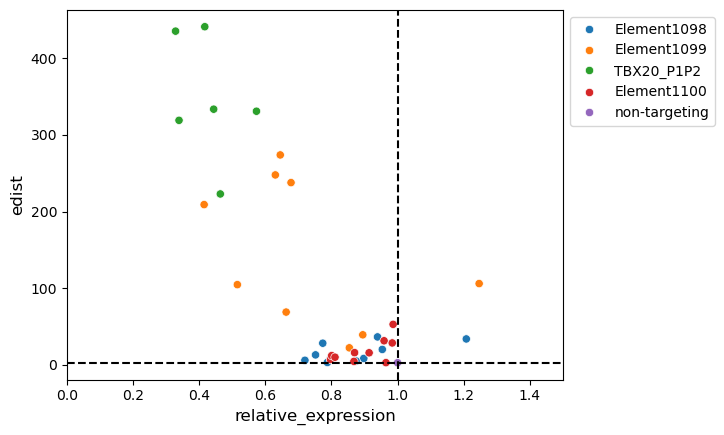

In [54]:
valid_region_list = ["non-targeting","TBX20_P1P2","Element1098","Element1099","Element1100"]
res_df_plot = res_df[(res_df["target_gene"]=="TBX20") & 
                     (np.isin(res_df["target_name"],valid_region_list))].copy()
nt_exp,nt_edist = res_df_plot.loc[res_df_plot["gRNA_name"]=="non-targeting",["expression","edist"]].values[0]
res_df_plot["relative_expression"] = res_df_plot["expression"]/nt_exp

plt.axvline(1,c="black",linestyle="--")
plt.axhline(nt_edist,c="black",linestyle="--")

sns.scatterplot(data=res_df_plot,x="relative_expression",y="edist",hue="target_name")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.xlim(0,1.5)
plt.savefig("TBX20_example.pdf")

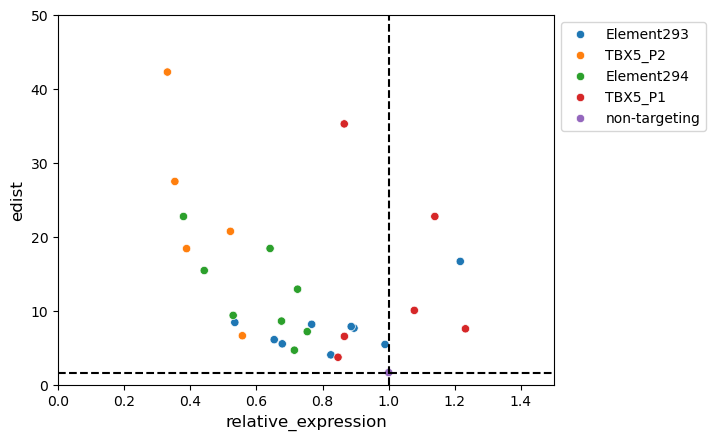

In [55]:
valid_region_list = ["non-targeting","TBX5_P1","TBX5_P2","Element293","Element294"]
res_df_plot = res_df[(res_df["target_gene"]=="TBX5") & 
                     (np.isin(res_df["target_name"],valid_region_list))]
nt_exp,nt_edist = res_df_plot.loc[res_df_plot["gRNA_name"]=="non-targeting",["expression","edist"]].values[0]

res_df_plot["relative_expression"] = res_df_plot["expression"]/nt_exp

plt.axvline(1,c="black",linestyle="--")
plt.axhline(nt_edist,c="black",linestyle="--")

sns.scatterplot(data=res_df_plot,x="relative_expression",y="edist",hue="target_name")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.ylim(0,50)
plt.xlim(0,1.5)
plt.savefig("TBX5_example.pdf")